# **NASA Predictive Maintenance - Remaining Useful Life (RUL) Prediction**
 This project focuses on estimating how much operational life an aircraft engine has left before maintenance is needed. Using historical engine performance data provided by NASA, the work aim to identify signs of wear over time and support earlier maintenance decisions. By improving the ability to recognize engines that are approaching the end of their service life, the project helps reduce the risk of unexpected failures and minimize operational downtime.

# **Dataset Description**
The dataset contains simulated sensor data from turbofan engines under various operational conditions. Each engine starts with normal operation and degrades over time until failure.

# **Columns:**
- `unit_number`: Engine ID (1-100)
- `time_cycles`: Operation cycles
- `setting_1, setting_2, setting_3`: Operational settings
- `s_1` through `s_21`: Sensor measurements (21 sensors)

# **Objectives**
1. Predict RUL for each engine in the test set
2. Compare multiple ML models (Regression, Classification, LSTM)
3. Identify key features for RUL prediction

# **Evaluation Metrics**
To assess how well our models predict Remaining Useful Life (RUL), we use four key statistical metrics:

# 1. Mean Squared Error (MSE)
MSE measures the average of the squared differences between predicted and actual RUL values. It penalizes larger errors more heavily than smaller ones, making it sensitive to outliers. A lower MSE indicates better predictive accuracy. For RUL prediction, MSE helps identify models that consistently make predictions close to the true remaining life.

# 2. Root Mean Squared Error (RMSE)
RMSE is the square root of MSE, bringing the error metric back to the original units (cycles). It provides a more intuitive understanding of prediction accuracy. For example, an RMSE of 4.60 cycles means the typical prediction error is about 4.6 operational cycles.

# 3. Mean Absolute Error (MAE)
MAE calculates the average absolute difference between predicted and actual RUL values. Unlike RMSE, MAE treats all errors equally without squaring them. This makes it more robust to outliers and easier to interpret in real-world terms.

# 4. R² Score (Coefficient of Determination)
R² represents the proportion of variance in the actual RUL values that is explained by the model. It ranges from 0 to 1, where 1 indicates perfect prediction and 0 indicates the model performs no better than simply predicting the mean RUL value.

In [16]:
# 1. Setup and Data Loading
# Import libraries
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
import os
import random

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Define column names
col_names = ['unit_number', 'time_cycles', 'setting_1', 'setting_2', 'setting_3']
sensor_names = [f's_{i}' for i in range(1, 22)]
col_names = col_names + sensor_names

# 2. Data Loading
print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
print("Dataset downloaded to:", dataset_path)

train_path = os.path.join("/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt")
test_path = os.path.join("/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt")
rul_path = os.path.join("/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt")

dftrain = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
dfvalid = pd.read_csv(test_path, sep=r"\s+", header=None, names=col_names)
y_valid = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])

print(f"Training data shape: {dftrain.shape}")
print(f"Test data shape: {dfvalid.shape}")
print(f"RUL labels shape: {y_valid.shape}")

Using Colab cache for faster access to the 'nasa-cmaps' dataset.
Dataset downloaded to: /kaggle/input/nasa-cmaps
Training data shape: (20631, 26)
Test data shape: (13096, 26)
RUL labels shape: (100, 1)


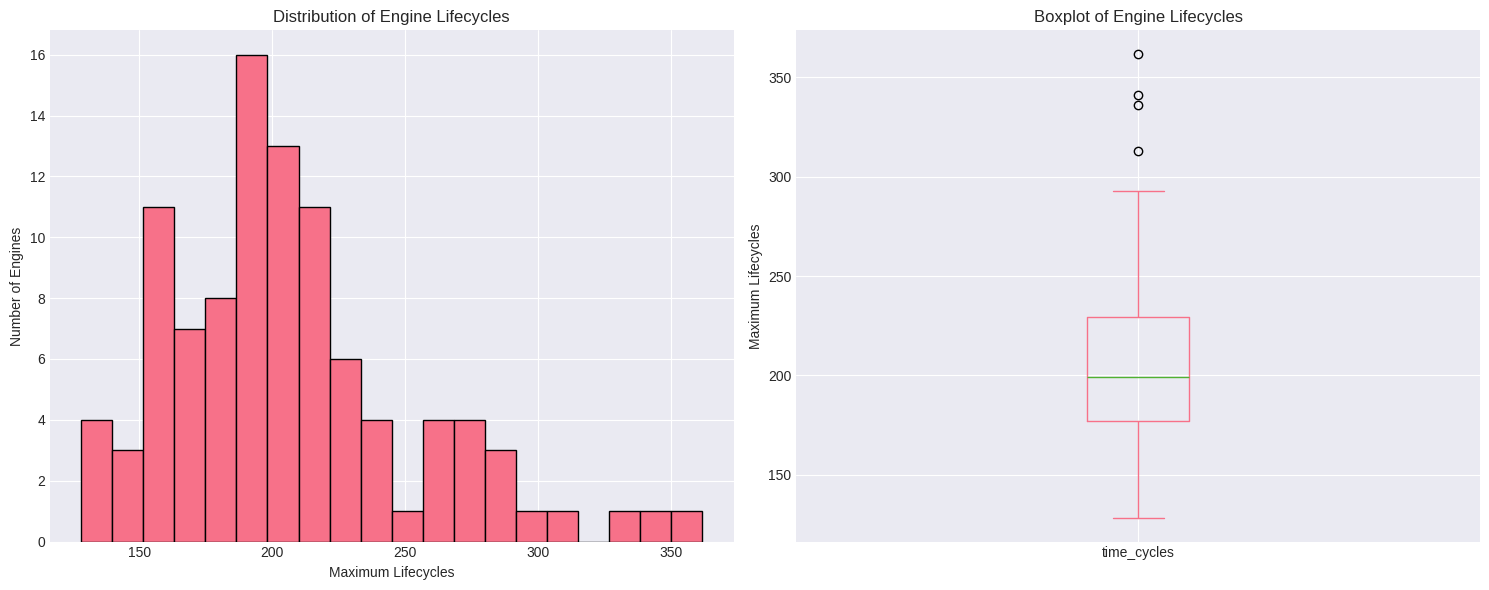

Average engine lifecycle: 206 cycles


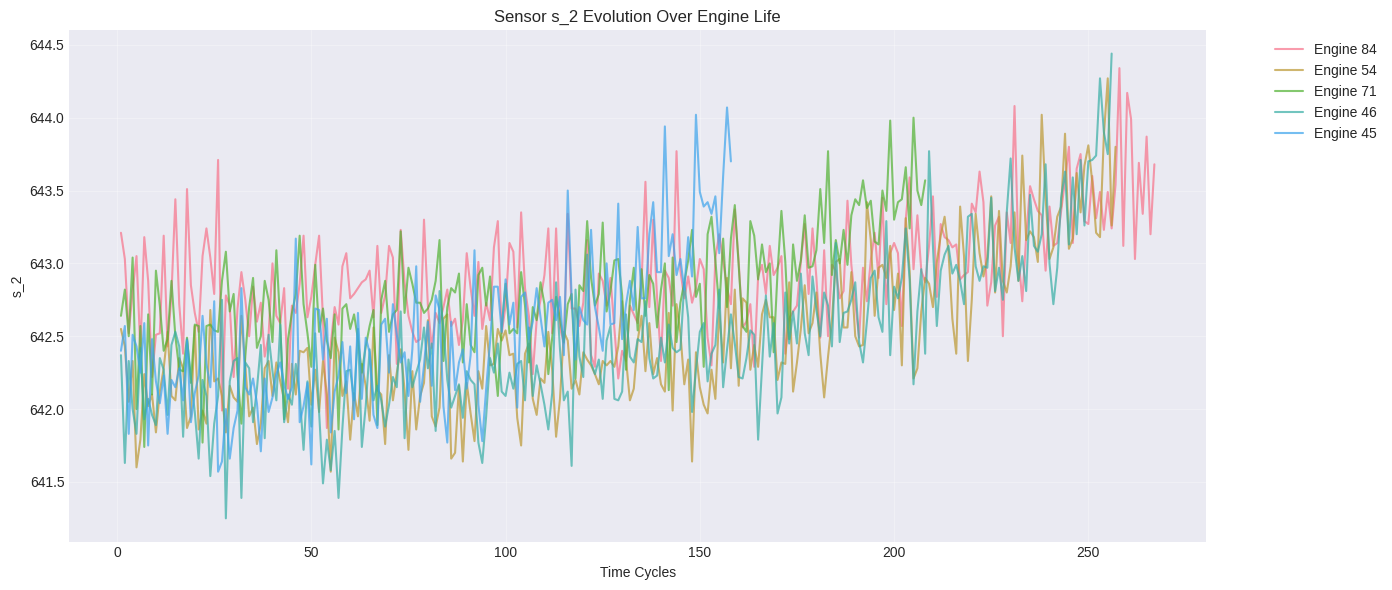

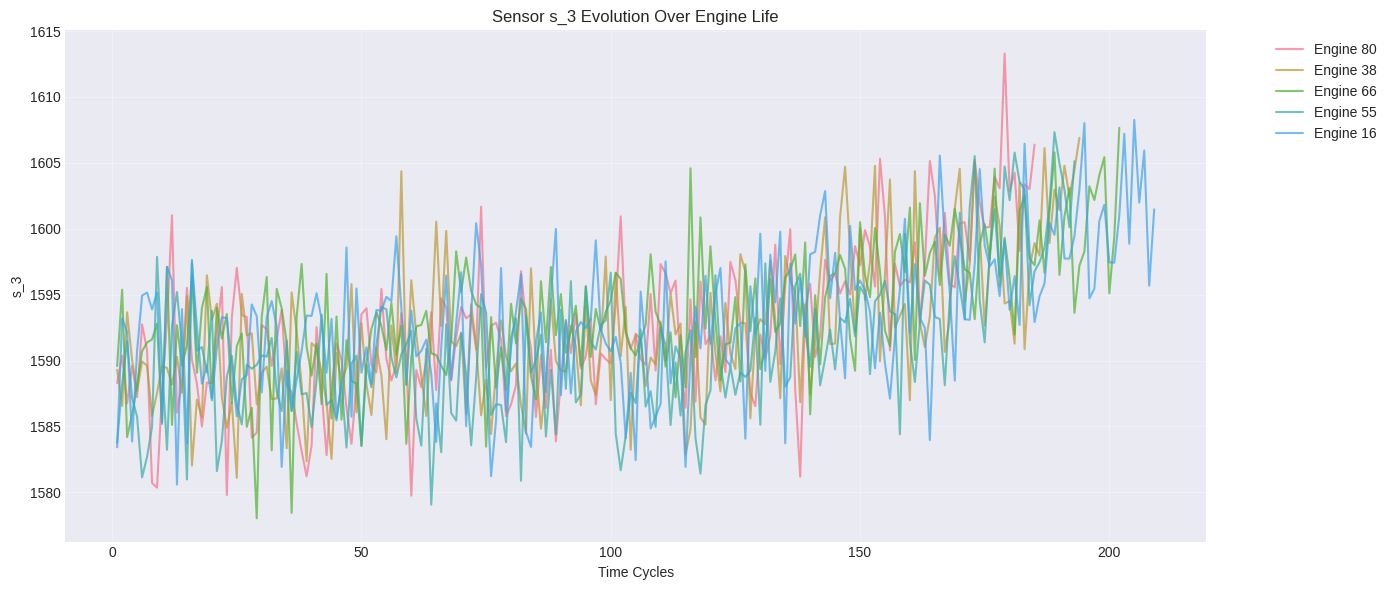

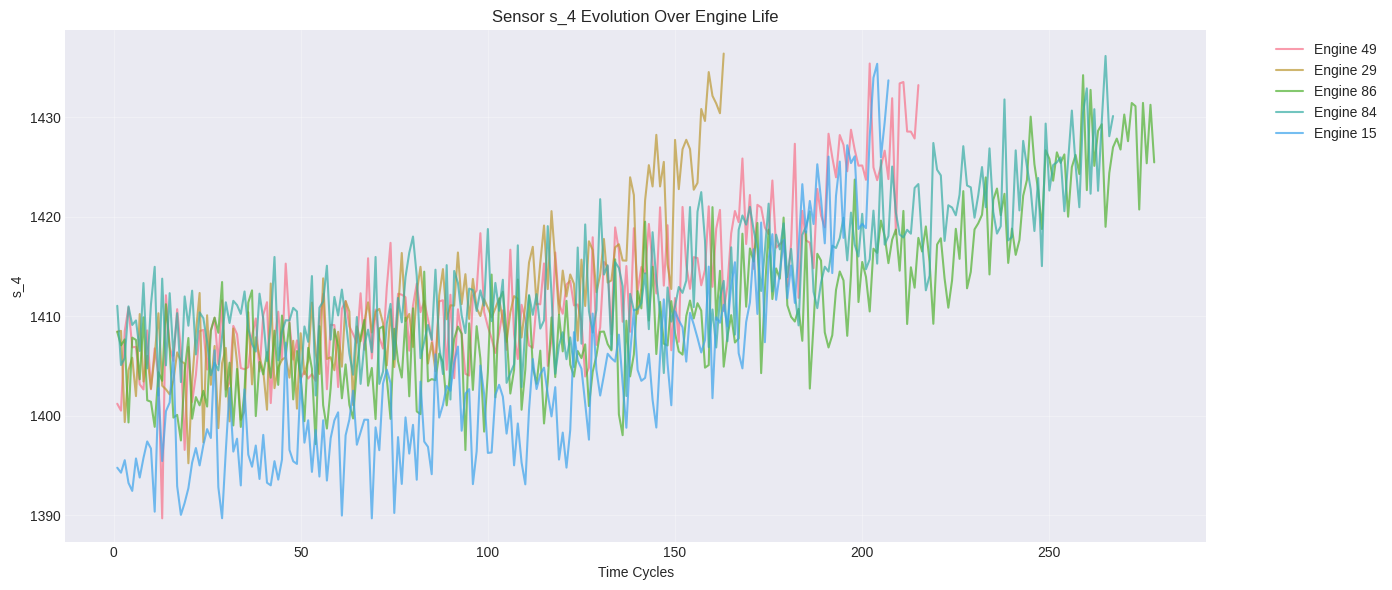

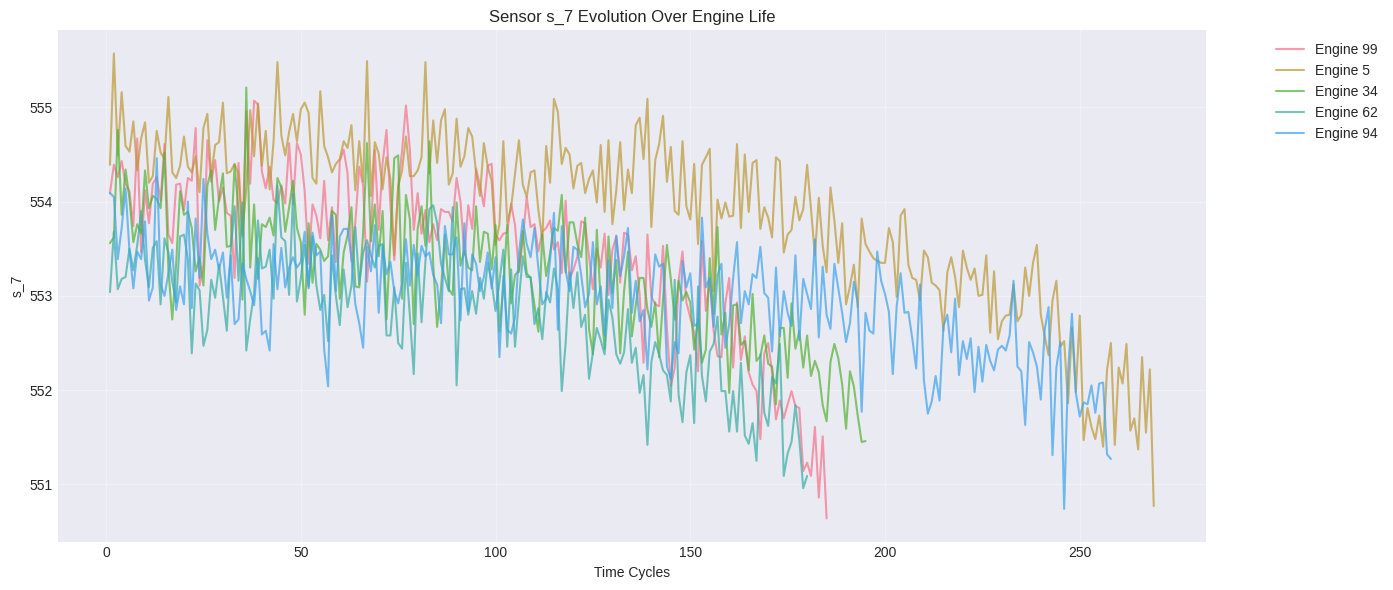

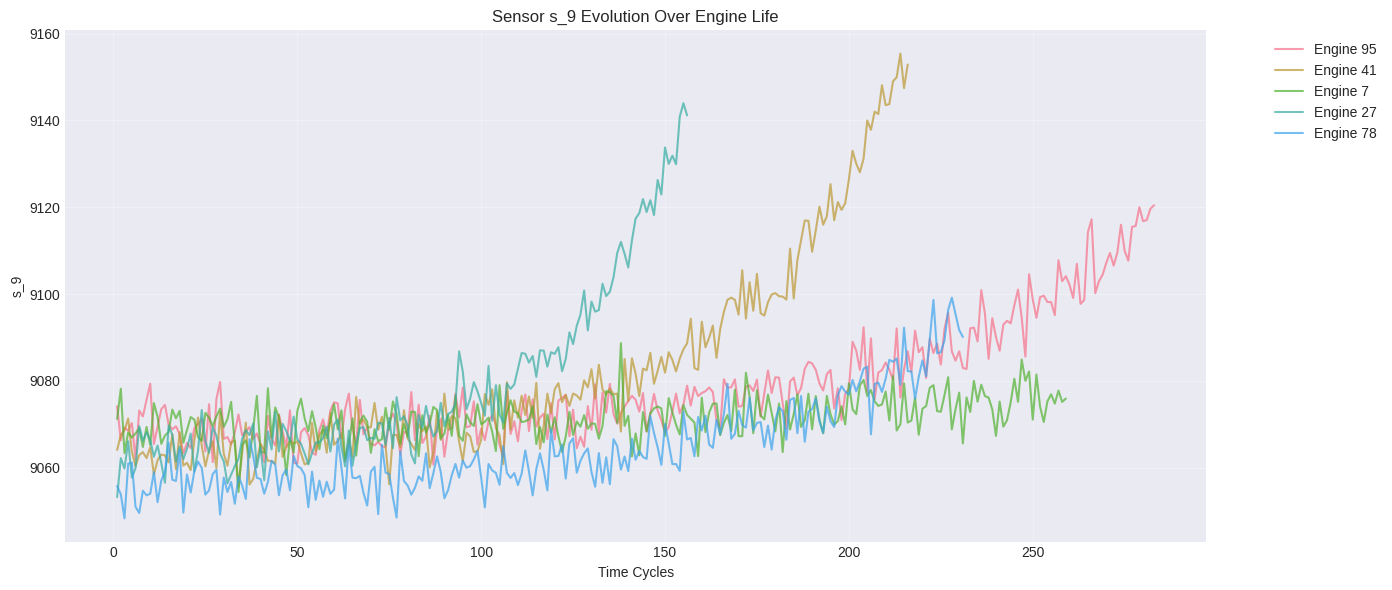

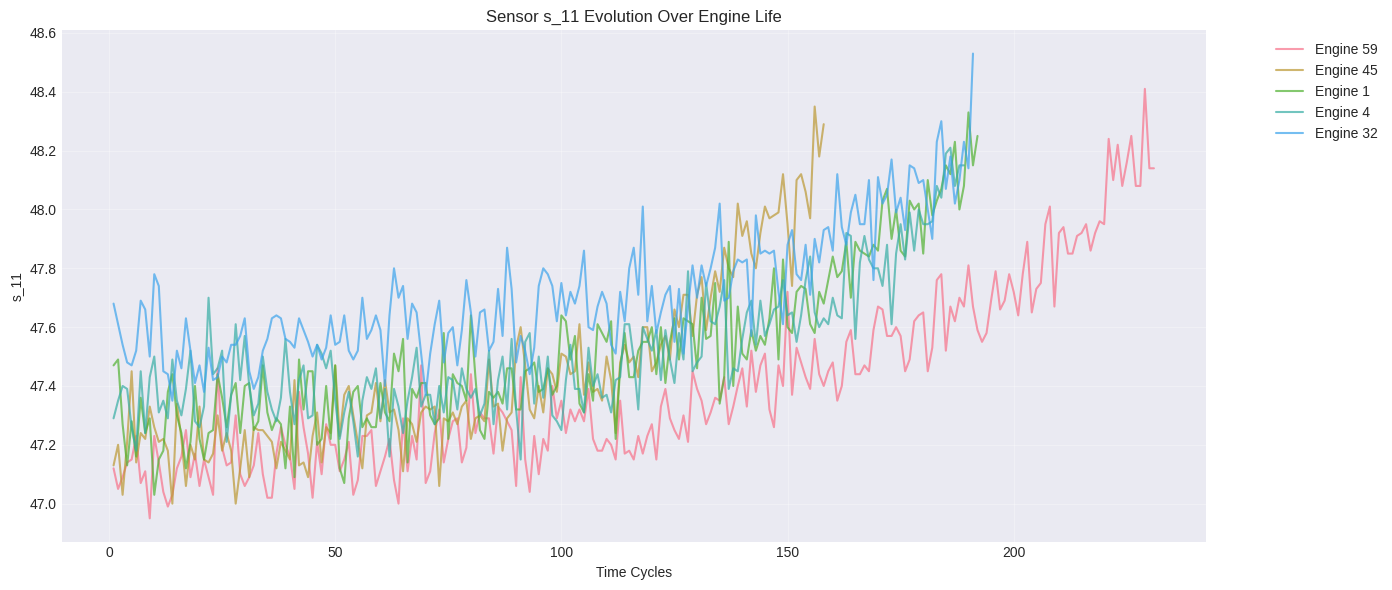

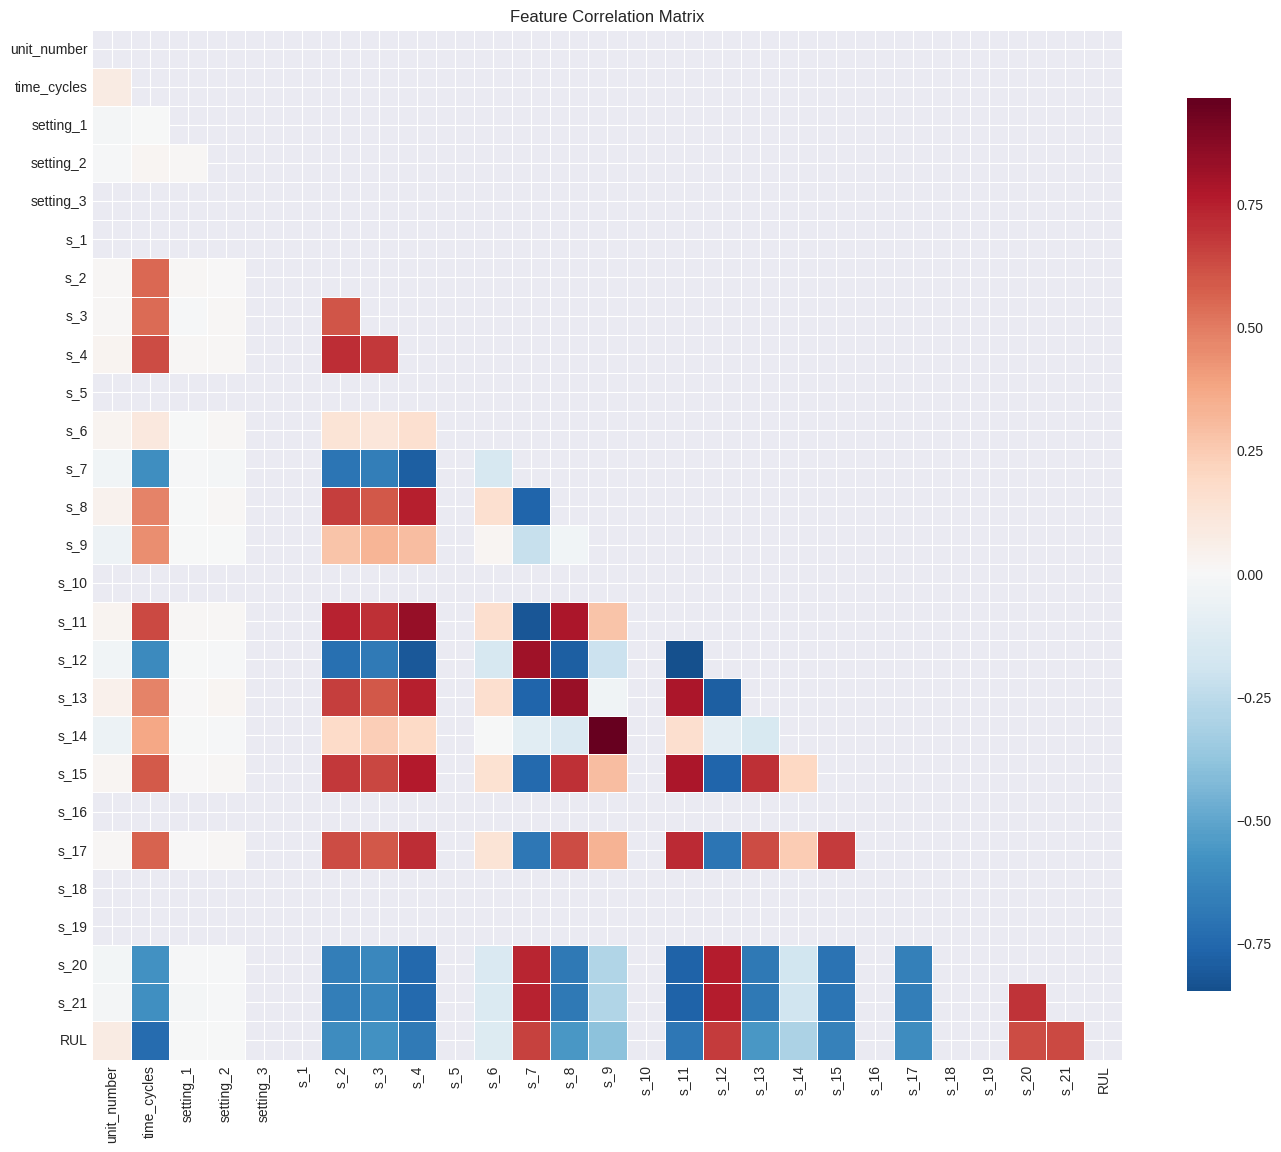

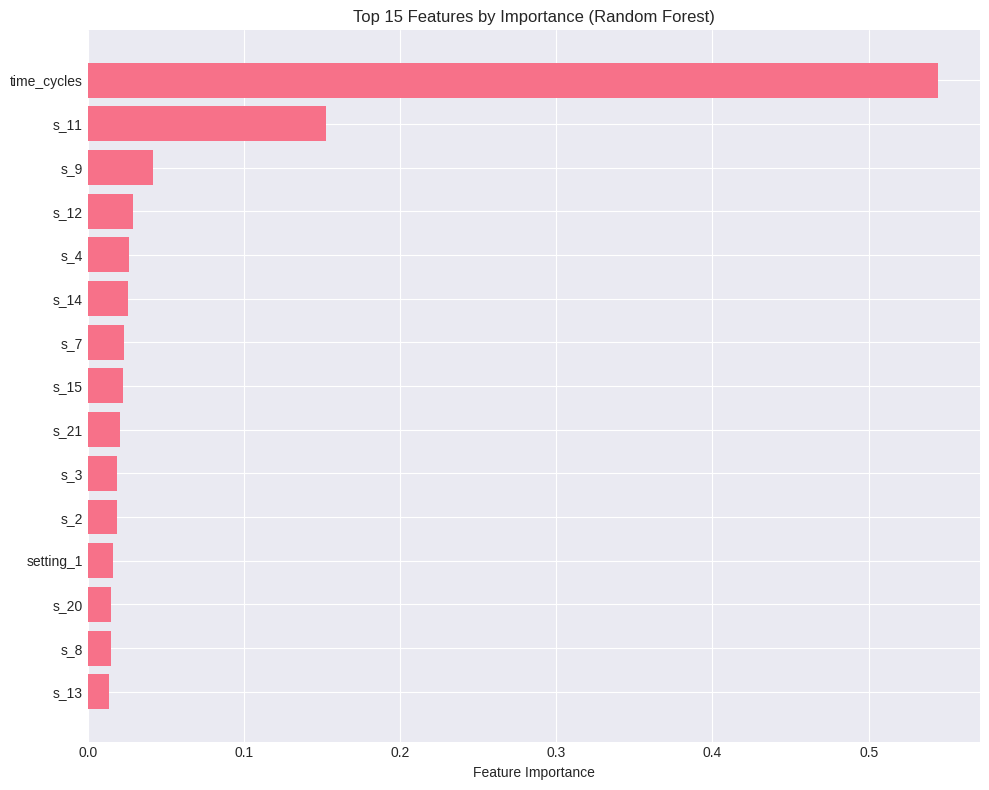

In [17]:
# 3. Exploratory Data Analysis (EDA)
train = dftrain.copy()
valid = dfvalid.copy()

# Check distribution of unit lifecycles
max_cycles = train.groupby('unit_number')['time_cycles'].max()

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
max_cycles.hist(bins=20, edgecolor='black')
plt.xlabel('Maximum Lifecycles')
plt.ylabel('Number of Engines')
plt.title('Distribution of Engine Lifecycles')

plt.subplot(1, 2, 2)
max_cycles.plot(kind='box')
plt.ylabel('Maximum Lifecycles')
plt.title('Boxplot of Engine Lifecycles')
plt.tight_layout()
plt.show()

print(f"Average engine lifecycle: {max_cycles.mean():.0f} cycles")

# Sensor Analysis
def plot_sensor_evolution(df, sensor_name, num_engines=5):
    plt.figure(figsize=(14, 6))
    engine_ids = np.random.choice(df['unit_number'].unique(),
                                  size=min(num_engines, 10),
                                  replace=False)
    for engine_id in engine_ids:
        engine_data = df[df['unit_number'] == engine_id]
        plt.plot(engine_data['time_cycles'], engine_data[sensor_name],
                 label=f'Engine {engine_id}', alpha=0.7)
    plt.xlabel('Time Cycles')
    plt.ylabel(sensor_name)
    plt.title(f'Sensor {sensor_name} Evolution Over Engine Life')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot key sensors
sensors_to_plot = ['s_2', 's_3', 's_4', 's_7', 's_9', 's_11']
for sensor in sensors_to_plot:
    plot_sensor_evolution(train, sensor, num_engines=5)

# Correlation Analysis
train_with_rul = train.copy()
train_with_rul['RUL'] = train_with_rul.groupby('unit_number')['time_cycles'].transform(
    lambda x: x.max() - x
)

corr_matrix = train_with_rul.corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Feature Importance Analysis
X_temp = train_with_rul.drop(['RUL', 'unit_number'], axis=1)
y_temp = train_with_rul['RUL']

rf_temp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X_temp, y_temp)

feature_importance = pd.DataFrame({
    'Feature': X_temp.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features by Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Training data shape: (20631, 49)
Test data shape: (13096, 49)
Training set size: 16504
Validation set size: 4127
Training Linear Regression...

Linear Regression Performance:
  MSE: 588.3787
  RMSE: 24.2565
  MAE: 16.1543
  R² Score: 0.8712

Training Ridge Regression...

Ridge Regression Performance:
  MSE: 588.3699
  RMSE: 24.2563
  MAE: 16.1531
  R² Score: 0.8712

Training Lasso Regression...

Lasso Regression Performance:
  MSE: 587.9791
  RMSE: 24.2483
  MAE: 16.1328
  R² Score: 0.8713

Training Random Forest...

Random Forest Performance:
  MSE: 50.1946
  RMSE: 7.0848
  MAE: 1.9168
  R² Score: 0.9890

Training Gradient Boosting...

Gradient Boosting Performance:
  MSE: 21.2004
  RMSE: 4.6044
  MAE: 2.4424
  R² Score: 0.9954

Training SVR...

SVR Performance:
  MSE: 441.1544
  RMSE: 21.0037
  MAE: 10.6265
  R² Score: 0.9034

LSTM MODEL
LSTM Training samples: (15631, 50, 47)
LSTM Test samples: (8162, 50, 47)
Feature shape after scaling: (15631, 50, 47)
Target shape after scaling: (1

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 50, 128)        │        90,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 50, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,433 (603.25 KB)

 Trainable params: 153,985 (601.50 KB)

 Non-trainable params: 448 (1.75 KB)


Training LSTM model...
Epoch 1/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 46s 192ms/step - loss: 0.0443 - mae: 0.1494 - val_loss: 0.0284 - val_mae: 0.1215 - learning_rate: 0.0010
Epoch 2/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 37s 191ms/step - loss: 0.0119 - mae: 0.0809 - val_loss: 0.0048 - val_mae: 0.0475 - learning_rate: 0.0010
Epoch 3/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 38s 191ms/step - loss: 0.0067 - mae: 0.0606 - val_loss: 0.0039 - val_mae: 0.0391 - learning_rate: 0.0010
Epoch 4/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 38s 192ms/step - loss: 0.0048 - mae: 0.0508 - val_loss: 0.0080 - val_mae: 0.0618 - learning_rate: 0.0010
Epoch 5/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 193ms/step - loss: 0.0040 - mae: 0.0459 - val_loss: 0.0018 - val_mae: 0.0278 - learning_rate: 0.0010
Epoch 6/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 38s 193ms/step - loss: 0.0032 - mae: 0.0412 - val_loss: 0.0031 - val_mae: 0.0425 - learning_rate: 0.0010
Epoch 7/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 37s 191ms/step - loss: 0.0028 - mae: 0.0389 - val_loss: 0.0

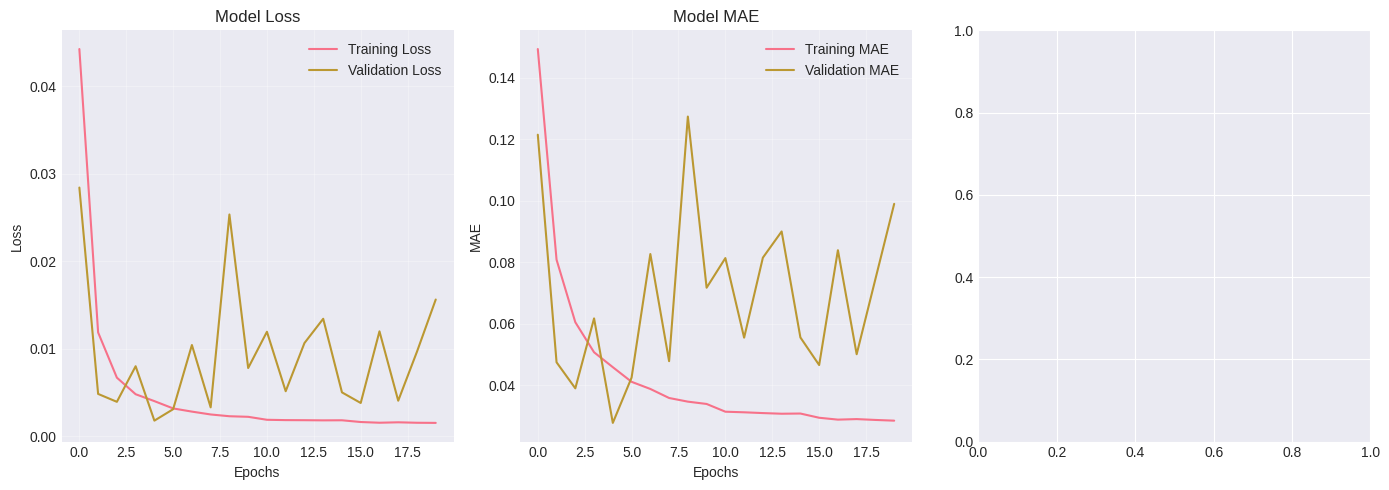


Evaluating LSTM model...
256/256 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step

LSTM Test Performance:
  MSE: 228.1646
  RMSE: 15.1051
  MAE: 11.9414
  R² Score: 0.8741


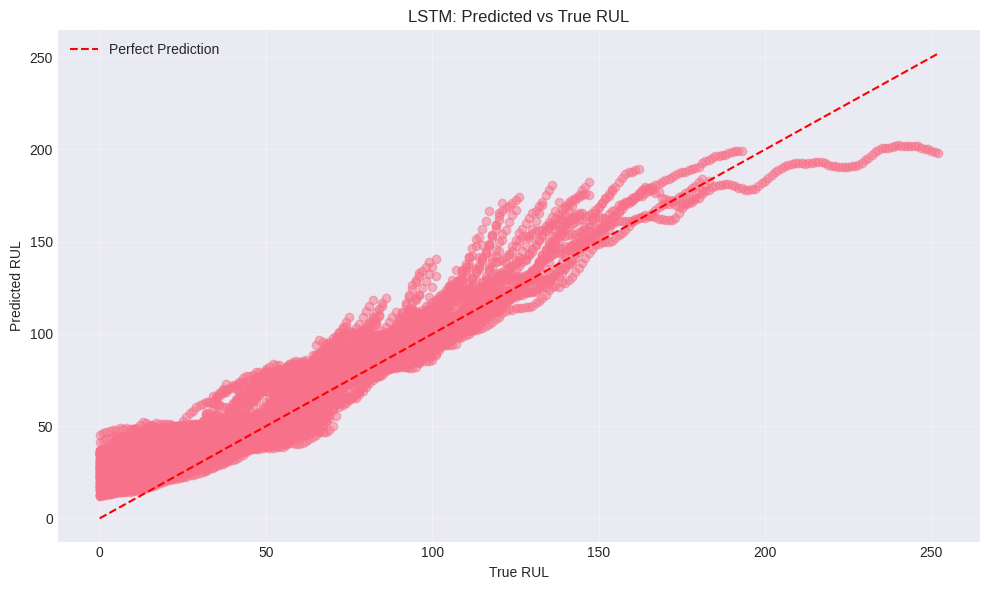

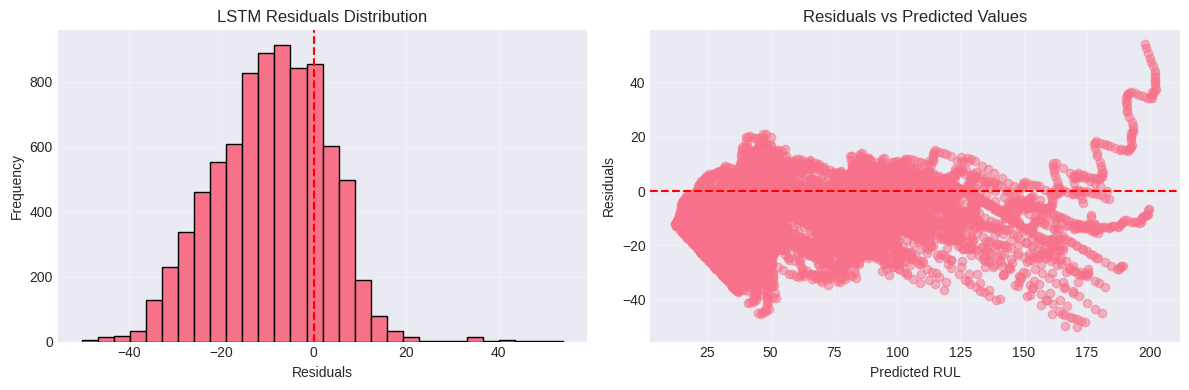

In [18]:
# 4. Feature Engineering
def add_rul_column(df):
    df_grouped = df.groupby('unit_number')
    max_cycles = df_grouped['time_cycles'].max()
    merged = df.merge(max_cycles.to_frame(name='max_cycles'),
                     left_on='unit_number', right_index=True)
    merged['RUL'] = merged['max_cycles'] - merged['time_cycles']
    merged = merged.drop('max_cycles', axis=1)
    return merged

def create_features(df):
    df_copy = df.copy()
    df_copy = add_rul_column(df_copy)
    max_cycles = df_copy.groupby('unit_number')['time_cycles'].transform('max')
    df_copy['cycle_pct'] = df_copy['time_cycles'] / max_cycles

    sensors = [f's_{i}' for i in range(1, 22)]
    for sensor in sensors:
        df_copy[f'{sensor}_rolling_mean'] = df_copy.groupby('unit_number')[sensor].transform(
            lambda x: x.rolling(window=5, min_periods=1).mean()
        )
    return df_copy

train_engineered = create_features(train)
valid_engineered = create_features(valid)

print(f"Training data shape: {train_engineered.shape}")
print(f"Test data shape: {valid_engineered.shape}")

# 5. Data Preparation for Modeling
def prepare_data_for_modeling(df, target_col='RUL'):
    X = df.drop([target_col, 'unit_number'], axis=1, errors='ignore')
    y = df[target_col]
    X = X.fillna(X.mean())
    return X, y

X_train, y_train = prepare_data_for_modeling(train_engineered)
X_valid, y_valid_clean = prepare_data_for_modeling(valid_engineered)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train_split)}")
print(f"Validation set size: {len(X_val_split)}")

# Prepare Data for LSTM
def prepare_lstm_data(df, seq_length=30):
    X, y = [], []
    for unit in df['unit_number'].unique():
        unit_data = df[df['unit_number'] == unit]
        features = unit_data.drop(['unit_number', 'RUL'], axis=1).values
        target = unit_data['RUL'].values
        for i in range(len(features) - seq_length):
            X.append(features[i:i+seq_length])
            y.append(target[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30
X_lstm_train, y_lstm_train = prepare_lstm_data(train_engineered, seq_length)
X_lstm_test, y_lstm_test = prepare_lstm_data(valid_engineered, seq_length)

X_lstm_scaled = scaler.fit_transform(X_lstm_train.reshape(-1, X_lstm_train.shape[-1]))
X_lstm_scaled = X_lstm_scaled.reshape(X_lstm_train.shape)

split_idx = int(0.8 * len(X_lstm_scaled))
X_lstm_train_split = X_lstm_scaled[:split_idx]
X_lstm_val_split = X_lstm_scaled[split_idx:]
y_lstm_train_split = y_lstm_train[:split_idx]
y_lstm_val_split = y_lstm_train[split_idx:]

# 6. Regression Models
def evaluate_model(model, X_test, y_test, model_name="Model"):
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"\n{model_name} Performance:")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R² Score: {r2:.4f}")
    return predictions, {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Store all results for comparison
all_model_results = {}
all_predictions = {}

# Linear Models
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_split, y_train_split)
lr_pred, lr_results = evaluate_model(lr_model, X_val_split, y_val_split, "Linear Regression")
all_model_results['Linear Regression'] = lr_results
all_predictions['Linear Regression'] = lr_pred

print("\nTraining Ridge Regression...")
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_split, y_train_split)
ridge_pred, ridge_results = evaluate_model(ridge_model, X_val_split, y_val_split, "Ridge Regression")
all_model_results['Ridge'] = ridge_results
all_predictions['Ridge'] = ridge_pred

print("\nTraining Lasso Regression...")
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_split, y_train_split)
lasso_pred, lasso_results = evaluate_model(lasso_model, X_val_split, y_val_split, "Lasso Regression")
all_model_results['Lasso'] = lasso_results
all_predictions['Lasso'] = lasso_pred

# Tree-based Models
print("\nTraining Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20,
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train_split, y_train_split)
rf_pred, rf_results = evaluate_model(rf_model, X_val_split, y_val_split, "Random Forest")
all_model_results['Random Forest'] = rf_results
all_predictions['Random Forest'] = rf_pred

print("\nTraining Gradient Boosting...")
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                     learning_rate=0.1, random_state=42)
gb_model.fit(X_train_split, y_train_split)
gb_pred, gb_results = evaluate_model(gb_model, X_val_split, y_val_split, "Gradient Boosting")
all_model_results['Gradient Boosting'] = gb_results
all_predictions['Gradient Boosting'] = gb_pred

print("\nTraining SVR...")
svr_model = SVR(kernel='rbf', C=10, gamma='scale')
svr_model.fit(X_train_split, y_train_split)
svr_pred, svr_results = evaluate_model(svr_model, X_val_split, y_val_split, "SVR")
all_model_results['SVR'] = svr_results
all_predictions['SVR'] = svr_pred

# 7. LSTM Model
print("\n" + "="*70)
print("LSTM MODEL")
print("="*70)

# Prepare data for LSTM with proper scaling
def prepare_lstm_data_improved(df, seq_length=30):
    """Prepare sequence data for LSTM model with proper scaling"""
    X, y = [], []

    for unit in df['unit_number'].unique():
        unit_data = df[df['unit_number'] == unit]

        # Get features and target
        features = unit_data.drop(['unit_number', 'RUL'], axis=1).values
        target = unit_data['RUL'].values

        # Create sequences
        for i in range(len(features) - seq_length):
            X.append(features[i:i+seq_length])
            y.append(target[i+seq_length])

    return np.array(X), np.array(y)

# Prepare LSTM data with longer sequence
seq_length = 50  # Increased sequence length
X_lstm_train, y_lstm_train = prepare_lstm_data_improved(train_engineered, seq_length)
X_lstm_test, y_lstm_test = prepare_lstm_data_improved(valid_engineered, seq_length)

print(f"LSTM Training samples: {X_lstm_train.shape}")
print(f"LSTM Test samples: {X_lstm_test.shape}")

# Scale features for LSTM separately (MinMaxScaler works better for LSTM)
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Reshape for scaling
X_train_flat = X_lstm_train.reshape(-1, X_lstm_train.shape[-1])
X_test_flat = X_lstm_test.reshape(-1, X_lstm_test.shape[-1])

# Scale features
X_train_scaled_flat = feature_scaler.fit_transform(X_train_flat)
X_test_scaled_flat = feature_scaler.transform(X_test_flat)

# Reshape back to sequences
X_train_scaled = X_train_scaled_flat.reshape(X_lstm_train.shape)
X_test_scaled = X_test_scaled_flat.reshape(X_lstm_test.shape)

# Scale target (RUL values)
y_train_scaled = target_scaler.fit_transform(y_lstm_train.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_lstm_test.reshape(-1, 1)).flatten()

print(f"Feature shape after scaling: {X_train_scaled.shape}")
print(f"Target shape after scaling: {y_train_scaled.shape}")

# Split training data
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.2, random_state=42
)

print(f"Training set: {X_train_split.shape[0]} samples")
print(f"Validation set: {X_val_split.shape[0]} samples")

# Build improved LSTM model
def build_lstm_model_improved(input_shape):
    """Build improved LSTM model with proper architecture"""
    model = keras.Sequential([
        # First LSTM layer with more units
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Second LSTM layer
        layers.LSTM(64, return_sequences=True),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Third LSTM layer
        layers.LSTM(32, return_sequences=False),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Dense layers
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)  # Linear activation for regression
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

# Build model
lstm_model = build_lstm_model_improved((X_train_split.shape[1], X_train_split.shape[2]))
lstm_model.summary()

# Early stopping with restore best weights
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Learning rate scheduler
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train model
print("\nTraining LSTM model...")
history = lstm_model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot training history
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Model MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# Plot learning rate if available
if 'lr' in history.history:
    plt.plot(history.history['lr'])
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate LSTM
print("\nEvaluating LSTM model...")
lstm_predictions_scaled = lstm_model.predict(X_test_scaled)
lstm_predictions = target_scaler.inverse_transform(lstm_predictions_scaled)

# Calculate metrics
lstm_mse = mean_squared_error(y_lstm_test, lstm_predictions)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = mean_absolute_error(y_lstm_test, lstm_predictions)
lstm_r2 = r2_score(y_lstm_test, lstm_predictions)

print(f"\nLSTM Test Performance:")
print(f"  MSE: {lstm_mse:.4f}")
print(f"  RMSE: {lstm_rmse:.4f}")
print(f"  MAE: {lstm_mae:.4f}")
print(f"  R² Score: {lstm_r2:.4f}")

# Compare actual vs predicted for LSTM
plt.figure(figsize=(10, 6))
plt.scatter(y_lstm_test, lstm_predictions, alpha=0.5)
plt.plot([0, max(y_lstm_test)], [0, max(y_lstm_test)], 'r--', label='Perfect Prediction')
plt.xlabel('True RUL')
plt.ylabel('Predicted RUL')
plt.title('LSTM: Predicted vs True RUL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot residuals for LSTM
residuals = y_lstm_test - lstm_predictions.flatten()
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('LSTM Residuals Distribution')
plt.axvline(x=0, color='red', linestyle='--')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(lstm_predictions, residuals, alpha=0.5)
plt.xlabel('Predicted RUL')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.axhline(y=0, color='red', linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Add LSTM to results
all_model_results['LSTM'] = {'MSE': lstm_mse, 'RMSE': lstm_rmse, 'MAE': lstm_mae, 'R2': lstm_r2}


Selected Model: Gradient Boosting
Validation RMSE: 4.6044
Validation MAE: 2.4424
Validation R²: 0.9954

Submission shape: (100, 3)
   Engine_ID  True_RUL  Predicted_RUL
0          1        30      20.582820
1          2        48      38.762062
2          3       125      68.766907
3          4       105      62.640374
4          5        97      59.814132


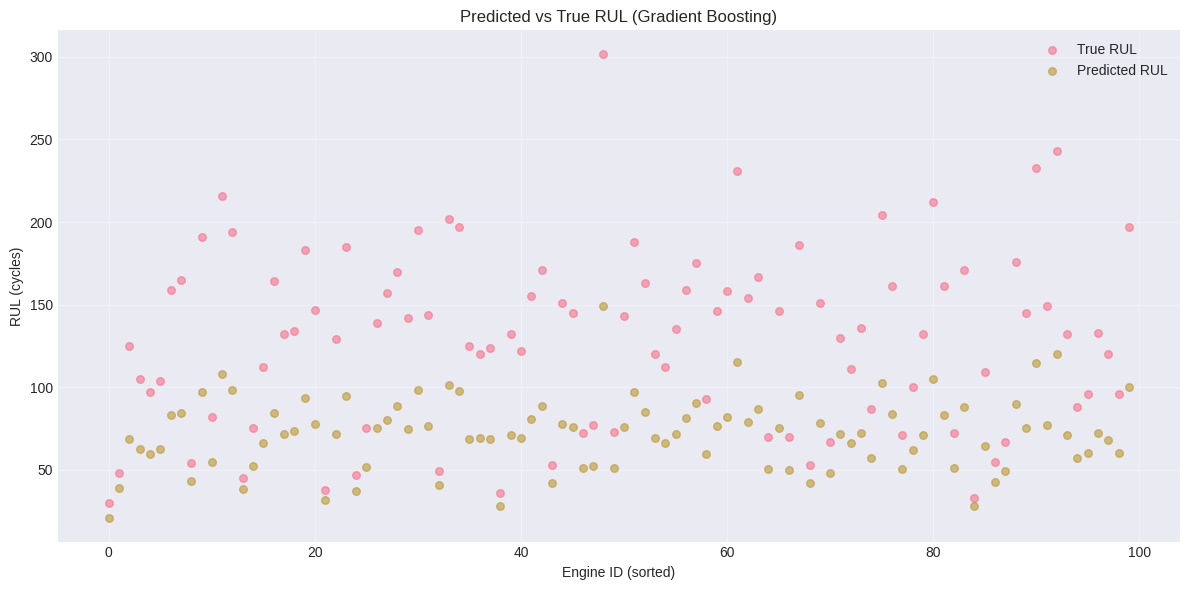

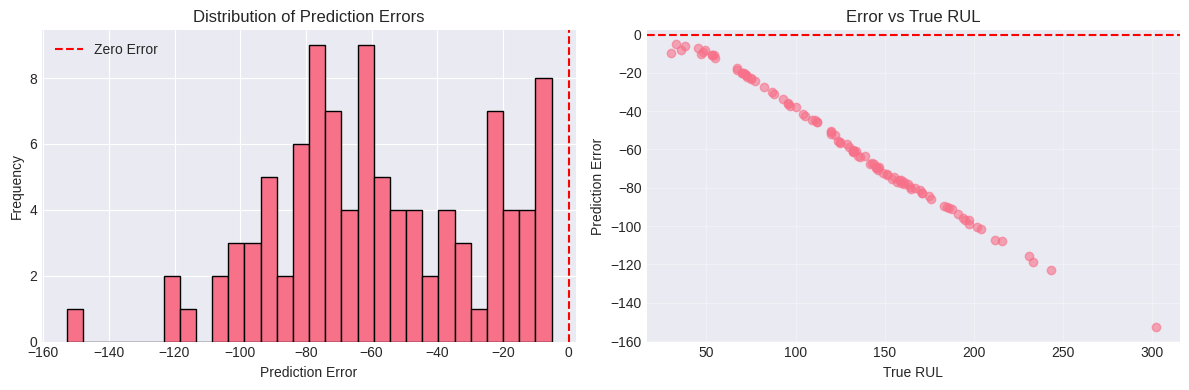

In [19]:
# 10. Final Model Selection and Prediction
# Choose best performing model (Gradient Boosting based on results)
best_model = gb_model
print(f"\nSelected Model: Gradient Boosting")
print(f"Validation RMSE: {gb_results['RMSE']:.4f}")
print(f"Validation MAE: {gb_results['MAE']:.4f}")
print(f"Validation R²: {gb_results['R2']:.4f}")

# Make final predictions on test set
test_predictions = best_model.predict(X_valid_scaled)

# Create submission DataFrame
submission = pd.DataFrame({
    'Engine_ID': valid['unit_number'].values,
    'True_RUL': y_valid_clean.values,
    'Predicted_RUL': test_predictions
})

# Aggregate predictions by engine (take mean prediction for each engine)
submission_agg = submission.groupby('Engine_ID').agg({
    'True_RUL': 'first',
    'Predicted_RUL': 'mean'
}).reset_index()

print(f"\nSubmission shape: {submission_agg.shape}")
print(submission_agg.head())

# Plot predictions vs actual
plt.figure(figsize=(12, 6))
submission_sorted = submission_agg.sort_values('Engine_ID')

plt.scatter(range(len(submission_sorted)), submission_sorted['True_RUL'],
            alpha=0.6, label='True RUL', s=30)
plt.scatter(range(len(submission_sorted)), submission_sorted['Predicted_RUL'],
            alpha=0.6, label='Predicted RUL', s=30)
plt.xlabel('Engine ID (sorted)')
plt.ylabel('RUL (cycles)')
plt.title('Predicted vs True RUL (Gradient Boosting)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Error analysis
errors = submission_agg['Predicted_RUL'] - submission_agg['True_RUL']
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(errors, bins=30, edgecolor='black')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(submission_agg['True_RUL'], errors, alpha=0.6)
plt.xlabel('True RUL')
plt.ylabel('Prediction Error')
plt.title('Error vs True RUL')
plt.axhline(y=0, color='red', linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()